# Milestone 1: Exploratory Data Analysis (EDA) Report
This notebook provides visual insights into ticket text lengths and class frequency distributions without saving heavy assets to disk.

In [ ]:
# Cell 1: Imports and Configuration
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config

# Apply clean visual styling inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

if not os.path.exists(config.CLEANED_DATA_PATH):
    print(f" Error: '{config.CLEANED_DATA_PATH}' not found. Run clean_corpus.py or train.py first!")
else:
    df = pd.read_csv(config.CLEANED_DATA_PATH)
    print(f" Successfully loaded {len(df):,} records for inline analysis.")

✅ Successfully loaded 16,338 records for inline analysis.


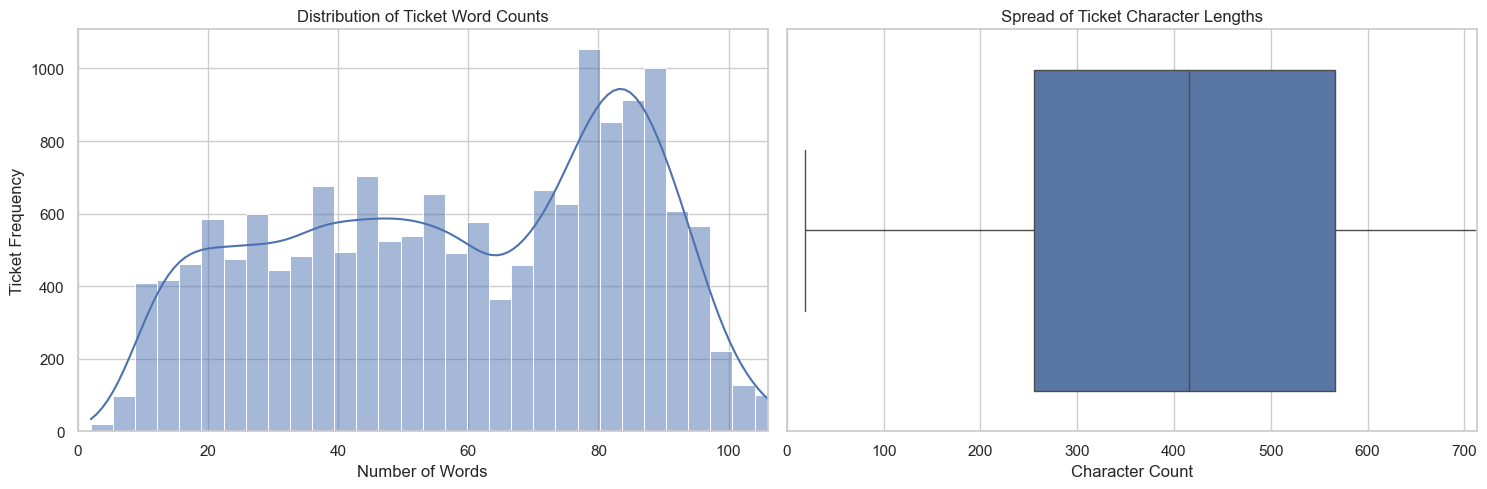

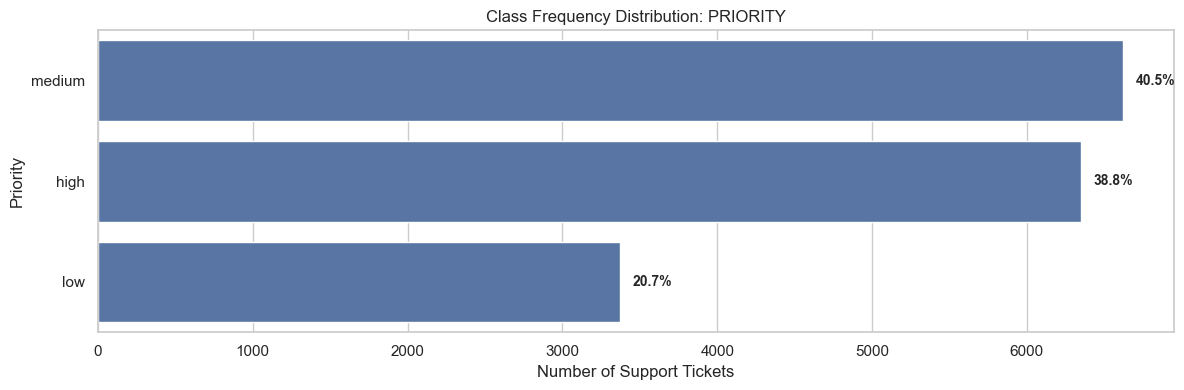

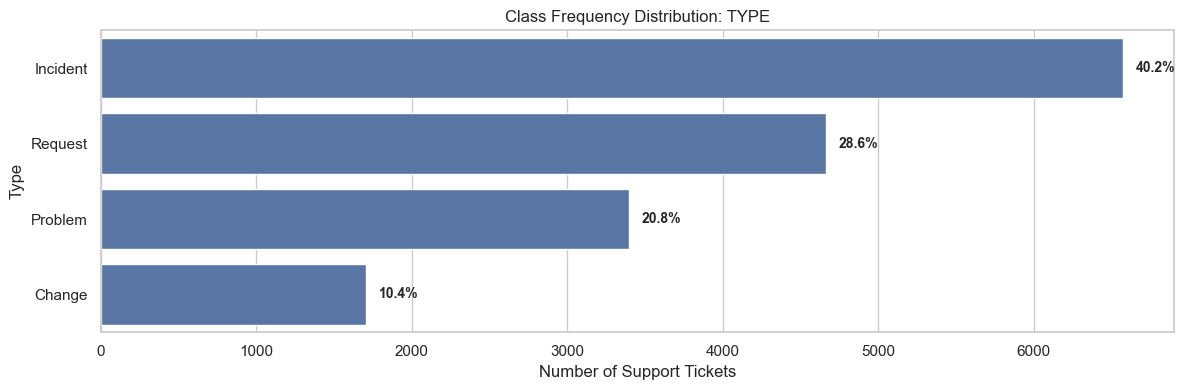

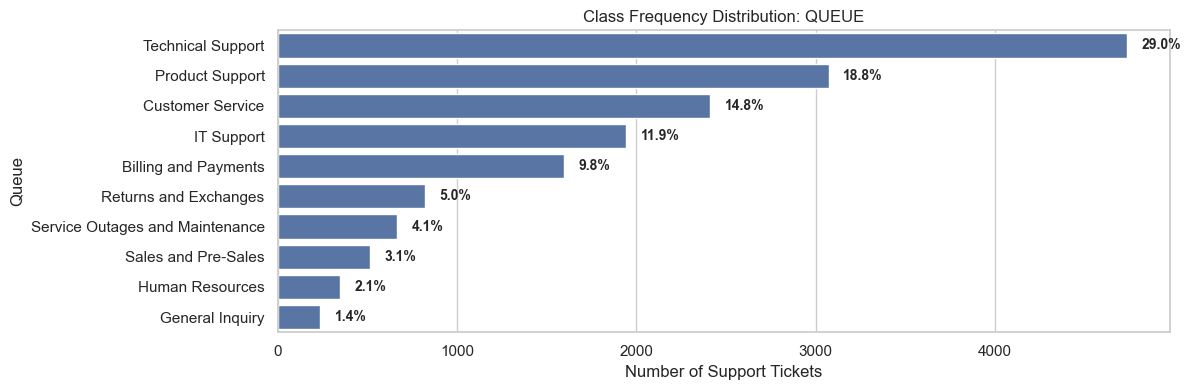

In [2]:
# Cell 2: Visual Distribution Plots
# Calculate word and character metrics on the fly
df['char_length'] = df['clean_body'].fillna('').astype(str).apply(len)
df['word_count'] = df['clean_body'].fillna('').astype(str).apply(lambda x: len(x.split()))

# --- Plot 1: Text Length Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['word_count'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Ticket Word Counts')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Ticket Frequency')
axes[0].set_xlim(0, df['word_count'].quantile(0.99))  # Clip extreme outliers for clean view

sns.boxplot(x=df['char_length'], ax=axes[1])
axes[1].set_title('Spread of Ticket Character Lengths')
axes[1].set_xlabel('Character Count')
axes[1].set_xlim(0, df['char_length'].quantile(0.99))
plt.tight_layout()
plt.show()

# --- Plot 2: Categorical Target Frequencies ---
categorical_targets = ['priority', 'type', 'queue']
for target in categorical_targets:
    if target in df.columns:
        plt.figure(figsize=(12, 4))
        order = df[target].value_counts().index
        ax = sns.countplot(y=target, data=df, order=order)

        # Overlay percentage share markers dynamically
        total = len(df[target])
        for p in ax.patches:
            percentage = f'{100 * p.get_width() / total:.1f}%'
            x_pos = p.get_width() + (total * 0.005)
            y_pos = p.get_y() + p.get_height() / 2
            ax.annotate(percentage, (x_pos, y_pos), va='center', ha='left', weight='bold')
            
        plt.title(f'Class Frequency Distribution: {target.upper()}')
        plt.xlabel('Number of Support Tickets')
        plt.ylabel(f'{target.capitalize()}')
        plt.tight_layout()
        plt.show()